## Свойства оценок и доверительные интервалы

В этом ноутбуке рассматриваются различные свойства точечных оценок и доверительных интервалов.

In [1]:
from typing import Any, Callable, List, Tuple

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps
import seaborn as sns
from matplotlib.lines import Line2D

sns.set(style="whitegrid", font_scale=1.25, palette="Set2")

ORANGE = "#ec7c26"
VIOLET = "#bc13fe"

np.random.seed(42)

### 1. Несмещенность оценок

Пусть $X_1, ..., X_n$ &mdash; выборка из распределения $\mathcal{N}(0, \sigma^2)$. Известно, что в качестве оценки параметра $\sigma^2$ можно использовать следующие оценки $S^2, \frac{n}{n-1}S^2$.

**Напоминание:** $S^2 := \frac{1}{n} \sum\limits_{i = 1}^{n} \left(X_i - \overline{X}\right)^2 = \overline{X^2} - \overline{X}^2$

**Вопрос:** Какие из этих оценок являются несмещенными?

**Ответ:** $\frac{n}{n-1}S^2$.

$\mathsf{E}_\sigma S^2 = \mathsf{E}_\sigma \overline{X^2} - \mathsf{E}_\sigma \overline{X}^2$ 
= $\frac{1}{n}\mathsf{E}_\sigma \sum\limits_{i=1}^{n}X_i^2 - \frac{1}{n^2}\mathsf{E}_\sigma \sum\limits_{i=1}^{n} X_i^2 - \frac{1}{n^2}\sum\limits_{i \neq j} \mathsf{E}_\sigma X_i X_j$ 
= $\frac{n-1}{n}\mathsf{E}_\sigma X^2 - \frac{n(n-1)}{n^2} \mathsf{E}_\sigma X^2$
= $\frac{n-1}{n}\mathsf{D}_\sigma X$

Получаем
* $S^2$ &mdash; смещенная оценка,
* $\frac{n}{n-1}S^2$ &mdash; несмещенная оценка $\sigma^2$, ее также называют исправленной выборочной дисперсией. 

Реализуем функции, вычисляющие оценки по набору выборок. У матрицы, заданной в виде `numpy.array` есть метод `var` вычисляющий выборочную дисперсию. Мы указываем аргумент `axis=-1`, чтобы указать, что дисперсию необходимо посчитать только по последней оси матрицы. Например, если у нас есть 500 выборок размера 100, которые заданы матрицей размера (500, 100), то такая функция посчитает выборочную дисперсию по каждой выборке и вернет 500 чисел. Аргумент `ddof` отвечает за поправку в нормирующем множителе, если он указан, то деление происходит на $n - ddof$.

In [2]:
def estimate_s2(X: np.ndarray) -> np.ndarray:
    """Смещенная оценка дисперсии"""
    return X.var(axis=-1)


def estimate_s2_corrected(X: np.ndarray) -> np.ndarray:
    """Несмещенная оценка дисперсии"""
    return X.var(axis=-1, ddof=1)

Зададим список оценок и разные параметры для отрисовки графика

In [3]:
estimators = [
    (estimate_s2, "$S^2$", ORANGE, 0.0),
    (estimate_s2_corrected, "$\\frac{n}{n-1}S^2$", VIOLET, 0.1),
]

Напишем функцию, которая для каждой оценки визуализирует разброс реализаций оценки и ее среднее значение.

In [4]:
def est_plot(
    distribution: sps.rv_continuous,
    estimators: List[Tuple[Callable[[np.ndarray], np.ndarray], str, str, float]],
    sample_size: int,
    sample_count: int,
) -> None:
    """
    Построение графика разброса реализаций оценок и их средних значений.

    Аргументы:
        distribution: Распределение формата scipy.stats
        estimators: Список оценок и параметров для графиков (оценка, название, цвет, позиция_y)
        sample_size: Размер генерируемых выборок
        sample_count: Количество генерируемых выборок
    """

    X = distribution.rvs(size=(sample_count, sample_size))

    plt.figure(figsize=(18, 0.7 * len(estimators)))
    for estimator, name, color, y in estimators:
        E = estimator(X)

        plt.scatter(E, np.zeros(sample_count) + y, alpha=0.1, s=100, color=color, label=name)
        plt.scatter(E.mean(), y, marker="*", s=500, color="w", edgecolors="black")

    plt.vlines(1, -1, 1, color="r")
    plt.title("Размер выборки = %d" % sample_size)
    plt.yticks([])
    plt.legend()
    plt.xlim((0.6, 1.4))
    plt.ylim((-0.1, 0.1 * len(estimators)))

Вызываем функцию для разных размеров выборок

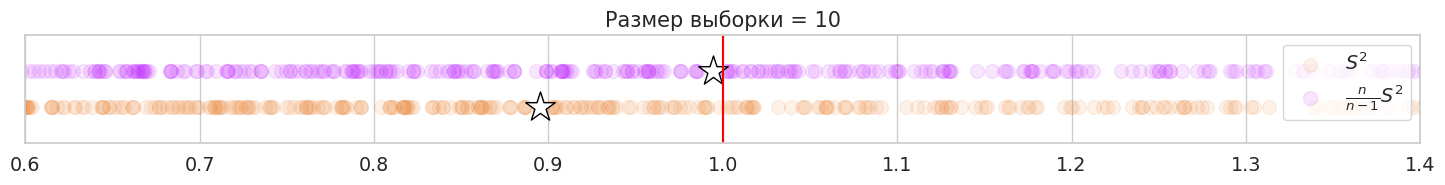

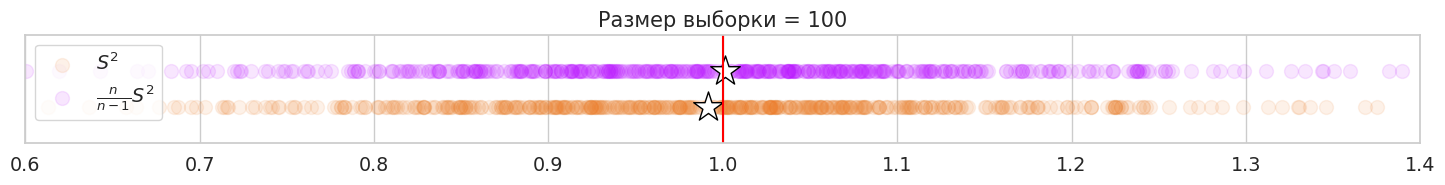

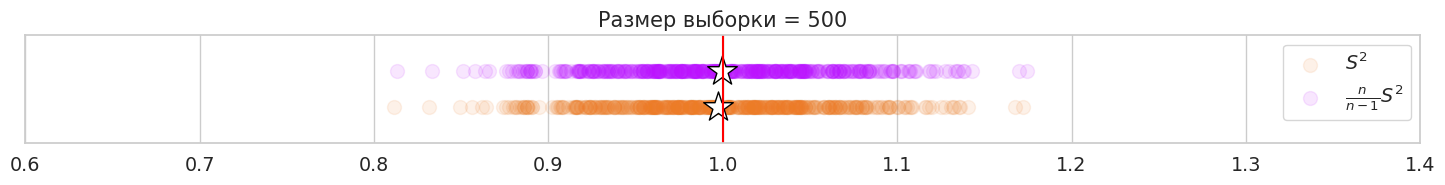

In [5]:
sample_size_list = (10, 100, 500)  # размеры выборок
sample_count = 500  # количество экспериментов

for sample_size in sample_size_list:
    est_plot(sps.norm, estimators, sample_size, sample_count)

**Вывод.** 

Несмещенность &mdash; свойство оценки в среднем быть равной параметру, который она оценивает. Иначе говоря, при бесконечном повторении эксперимента в среднем оценка будет равна истинному значению параметра.
Проведенные эксперименты подтверждают свойство несмещенности &mdash; среднее значение несмещенной оценки $\frac{n}{n-1}S^2$ оказалось примерно равно истинному значению параметра в отличии от смещенной оценки. Кроме того, можно заметить, что для смещенной оценки $S^2$ смещение уменьшается с ростом размера выборки, иначе говоря, она является *асимптотически несмещенной*.

В лабораторных работах скорректированные оценки используют, т.к. число опытов часто мало и $n$ нельзя считать достаточно большим. В таком случае отличие между несмещенными оценками и асимптотически несмещенными оценками становится существенным.

### 2. Состоятельность и асимптотическая нормальность оценок

Пусть $X_1, ..., X_n$ &mdash; выборка из распределения $Exp(\theta)$. Как известно из теории, оценка $\widehat{\theta} = 1/\overline{X}$ является *состоятельной* и *асимтотически нормальной* оценкой параметра $\theta$ с асимптотической дисперсией $\theta^2$. Визуализируем данные свойства.

Зададим параметры эксперимента, сгенерируем множество выборок, посчитаем по каждой из них оценку в зависимости от размера выборки.

In [6]:
theta = 2  # истинное значение параметра
size = 300  # размер выборок
samples_count = 500  # количество выборок
n_range = np.arange(size) + 1  # размеры подвыборок

# генерируем множество выборок,
# параметр theta является обратным к параметру масштаба
samples = sps.expon.rvs(size=(samples_count, size), scale=1 / theta)

# вычисляем оценки в зависимости от размера выборки,
# усредняем по последней оси
estimation = n_range / samples.cumsum(axis=1)

Визуализируем для каждой выборки все оценки в зависимости от размера выборки. Что же мы видим?

1. С ростом размера выборки траектории оценок сходятся к истинному значению параметра, об этом говорит свойство *состоятельности*.
2. Свойство *асимптотической нормальности* говорит о том, что с вероятностью около 0.95 при больших размерах выборки значение оценки отклоняется от истинного значения параметра не более чем на $2\theta\left/\sqrt{n}\right.$. Это также можно увидеть на графике.

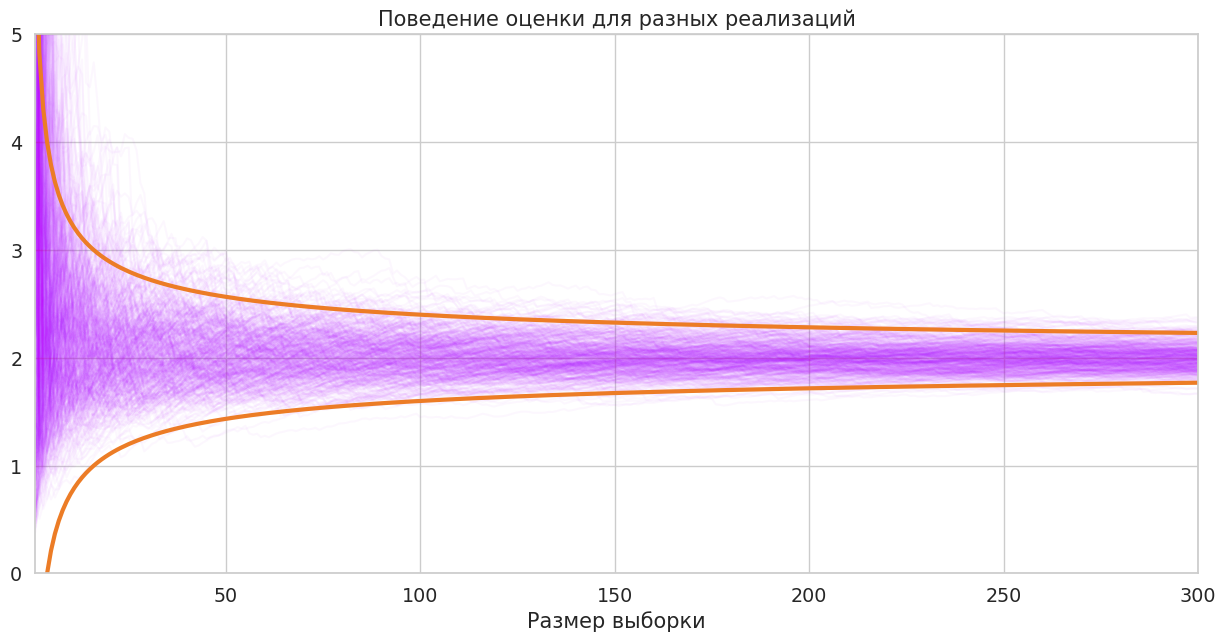

In [7]:
expect_deviation = 2 * theta / np.sqrt(n_range)

plt.figure(figsize=(15, 7))
for i in range(samples_count):
    plt.plot(np.arange(size) + 1, estimation[i], color=VIOLET, alpha=0.03)
plt.plot(n_range, theta + expect_deviation, color=ORANGE, lw=3)
plt.plot(n_range, theta - expect_deviation, color=ORANGE, lw=3)
plt.title("Поведение оценки для разных реализаций")
plt.xlabel("Размер выборки")
plt.ylim((0, 5))
plt.xlim((1, size));

Приблизим этот график в области малых размеров выборки. Тут мы можем видеть, что при малых размерах выборки асимтотические свойства не выполняются, в частности распределение оценки нельзя приблизить нормальным распределением. Приближения начинают выполняться начиная с размера выборки 30-50.

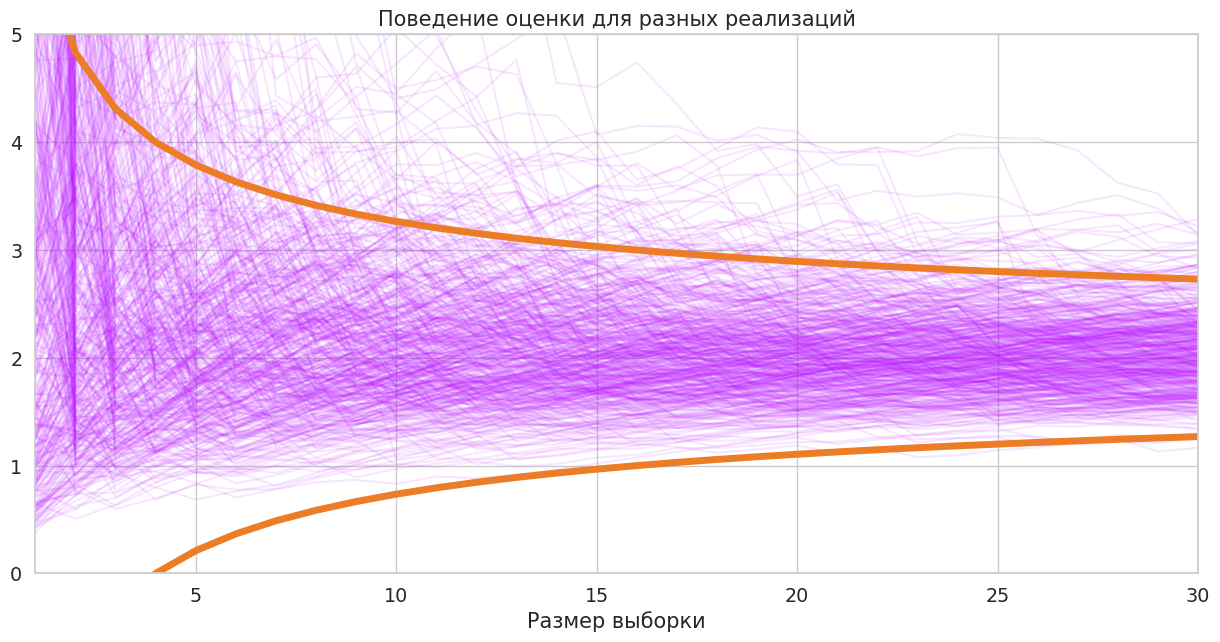

In [8]:
plt.figure(figsize=(15, 7))
for i in range(samples_count):
    plt.plot(np.arange(size) + 1, estimation[i], color=VIOLET, alpha=0.1)
plt.plot(n_range, theta + expect_deviation, color=ORANGE, lw=5)
plt.plot(n_range, theta - expect_deviation, color=ORANGE, lw=5)
plt.title("Поведение оценки для разных реализаций")
plt.xlabel("Размер выборки")
plt.ylim((0, 5))
plt.xlim((1, 30));

Посмотрим также, как себя ведут величины 
$$Z_n = \sqrt{n}\frac{\widehat{\theta} - \theta}{\theta},$$
распределение которых должно сходиться к стандартному нормальному.

На графике ниже видим, что при больших размерах выборки распределение похоже на стандратное нормальное.

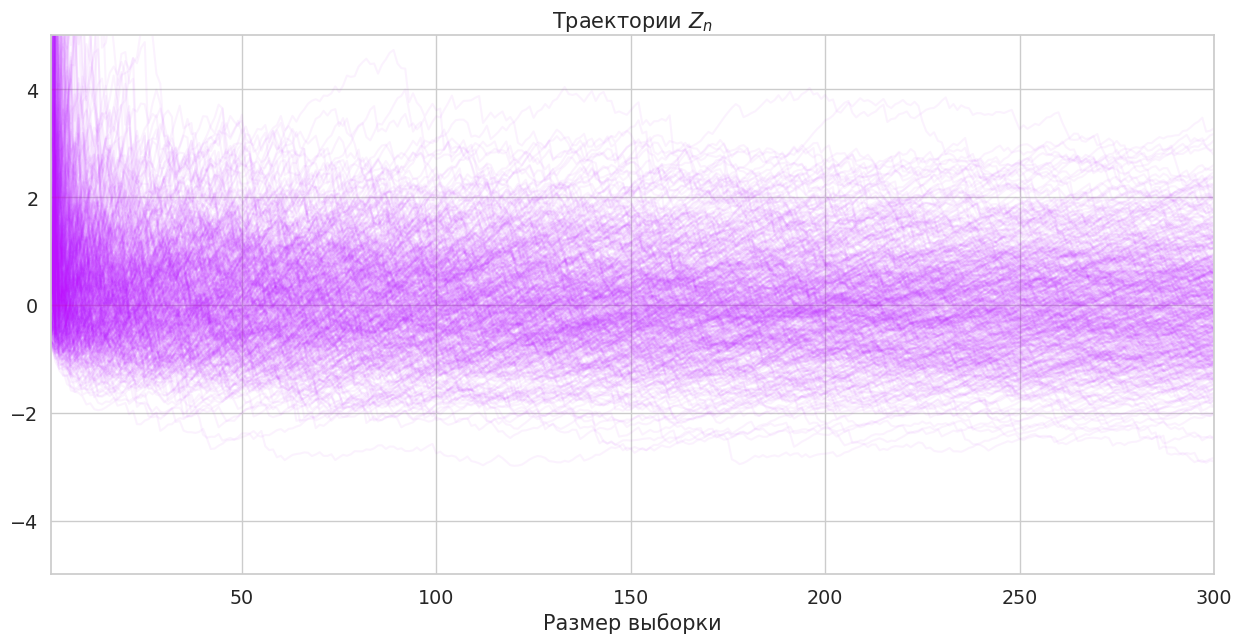

In [9]:
standardized = (estimation - theta) * np.sqrt(n_range) / theta

plt.figure(figsize=(15, 7))
for i in range(samples_count):
    plt.plot(np.arange(size) + 1, standardized[i], color=VIOLET, alpha=0.05)
plt.title("Траектории $Z_n$")
plt.xlabel("Размер выборки")
plt.ylim((-5, 5))
plt.xlim((1, size));

Для размера выборки 300 также построим гистрограмму значений величин $Z_n$. Видим, что она достаточно хорошо аппроксимируется стандартным нормальным распределением.

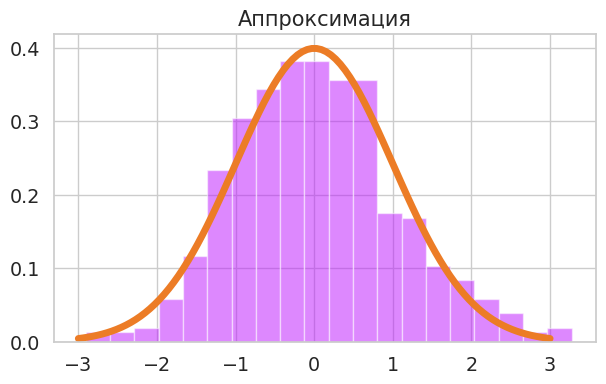

In [10]:
grid = np.linspace(-3, 3, 100)

plt.figure(figsize=(7, 4))
plt.hist(standardized[:, -1], bins=20, density=True, color=VIOLET, alpha=0.5)
plt.plot(grid, sps.norm.pdf(grid), lw=5, color=ORANGE)
plt.title("Аппроксимация");

### 3. Доверительные интервалы


Реализуем функции для вычисления доверительных интервалов для параметра бернуллиевского распределения

In [11]:
def get_wald_bern_confint(
    sample: np.ndarray, alpha: float = 0.95, axis: int = -1
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Построение доверительного интервала Вальда для набора выборок.

    Аргументы:
        sample: Массив содержащий выборки вдоль указанной оси
        alpha: Уровень доверия доверительного интервала
        axis: Ось вдоль которой вычисляются статистики

    Возвращает:
        Кортеж с левыми и правыми границами доверительных интервалов
    """

    mean = sample.mean(axis=axis)
    variance = mean * (1 - mean) / sample.shape[axis]
    quantile = sps.norm.ppf((1 + alpha) / 2)

    return mean - np.sqrt(variance) * quantile, mean + np.sqrt(variance) * quantile


def get_coverage_rate(
    ci_builder: Callable[[np.ndarray, float, int], Tuple[np.ndarray, np.ndarray]],
    sample: np.ndarray,
    theta_space: np.ndarray,
    alpha: float = 0.95,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Вычисляет долю покрытия параметра доверительным интервалом.

    Аргументы:
        ci_builder: Функция построения доверительных интервалов по выборке
        sample: Выборка для построения доверительных интервалов
        theta_space: Сетка значений параметра распределения Бернулли
        alpha: Уровень доверия для построения доверительных интервалов

    Возвращает:
        Кортеж с левыми границами, правыми границами, маской покрытия и долей покрытия
    """
    left, right = ci_builder(sample, alpha, axis=-1)
    covered = (left <= theta_space.reshape(-1, 1)) & (theta_space.reshape(-1, 1) <= right)
    mean_covered = np.mean(covered, axis=-1)
    return left, right, covered[0], mean_covered

#### 3.1. Интерпретация доверительного интервала

Для начала проиллюстрируем определение доверительного интервала.
Для этого
* сгенерируем большое число выборок из искомого распределения $Bern(\theta)$, 
* построим для каждой 95% доверительный интервал ($\alpha=0.95$),
* посмотрим, сколько из них пересекает истинное значение параметра.

Для наглядности пусть будет ровно 100 выборок.

In [12]:
NUM_EXPS = 100  # Число экспериментов всего
SAMPLE_SIZE = 60  # Размер выборки
ALPHA = 0.95  # Уровень доверия
THETA = 0.5  # Истинное значение параметра

# Генерация выборок
sample = sps.bernoulli.rvs(p=0.5, size=(NUM_EXPS, SAMPLE_SIZE))
sample_mean = np.mean(sample, axis=-1)

# Вычисление доверительных интервалов
left_ci, right_ci, covered_ci, coverage_rate = get_coverage_rate(
    get_wald_bern_confint, sample, np.array([THETA]), alpha=0.95
)

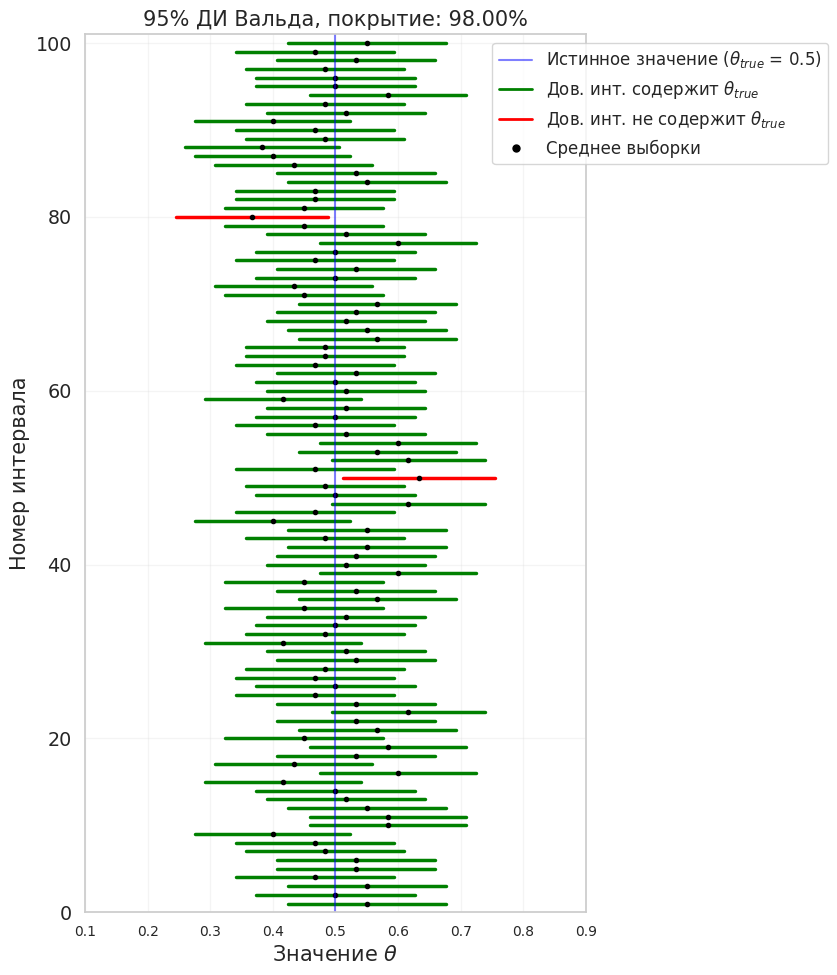

In [13]:
plt.figure(figsize=(10, 10))
for i, (ci_low, ci_high, cov) in enumerate(zip(left_ci, right_ci, covered_ci), start=1):
    color = "green" if cov else "red"
    plt.plot([ci_low, ci_high], [i, i], color=color, linewidth=2.5)
    plt.plot(sample_mean[i - 1], i, "ko", markersize=3)

plt.axvline(THETA, color="blue", alpha=0.5)

label_true = r"Истинное значение ($\theta_{true}$ = " + f"{THETA})"
legend_elements = [
    Line2D([0], [0], color="blue", alpha=0.5, label=label_true),
    Line2D([0], [0], color="green", linewidth=2, label=r"Дов. инт. содержит $\theta_{true}$"),
    Line2D([0], [0], color="red", linewidth=2, label=r"Дов. инт. не содержит $\theta_{true}$"),
    Line2D(
        [0], [0], marker="o", color="k", linestyle="None", markersize=5, label="Среднее выборки"
    ),
]
plt.xlim((0.1, 0.9))
plt.ylim((0, NUM_EXPS + 1))
plt.xlabel(r"Значение $\theta$")
plt.ylabel("Номер интервала")
plt.title(f"95% ДИ Вальда, покрытие: {coverage_rate[0]:.2%}")
plt.xticks(fontsize=10)
plt.legend(handles=legend_elements, bbox_to_anchor=(1.5, 1), loc="upper right", fontsize=12)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

**Вывод.**

Доверительный интервал необходимо интерпретировать как случайный объект, который при многократном повторении эксперимента в $\alpha \cdot 100\%$ случаев накрывает истинное значение $\theta$. В одной конкретной реализации истинное значение либо лежит, либо нет.

#### 3.2. Ширина доверительного интервала

Одним из важных параметров доверительных интервалов является ширина, $ u(x_1,...,x_n) - l (x_1,...,x_n)$. При прочих равных условиях считается: чем уже доверительный интервал, тем лучше.


Давайте оценим, как различные свойства выборки влияют на ширину доверительного интервала.

---

Зададим функции, которые рассчитывают теоретическую ширину соответствующего доверительного интервала.

In [14]:
def get_theoretical_ci_width_wald(prob: np.ndarray, size: int, alpha: float = 0.95) -> np.ndarray:
    """
    Вычисление теоретической ширины доверительного интервала Вальда.

    Аргументы:
        prob: Сетка значений параметра распределения Бернулли
        size: Размер выборки для вычисления ширины интервала
        alpha: Уровень доверия доверительного интервала

    Возвращает:
        Массив теоретических ширин доверительных интервалов
    """
    variance = prob * (1 - prob) / size
    quantile = sps.norm.ppf((1 + alpha) / 2)

    return 2 * np.sqrt(variance) * quantile


NUM_EXPS = 10_000

**В зависимости от значения $\theta_{true}$**

Для определения зависимости ширины доверительного интервала от значения истинной вероятности успеха $\theta_{true}$ в распределении Бернулли, создадим сетку параметра и для каждого рассчитаем границы доверительных интервалов. Размер выборки и количество независимых генериций одинаковы для каждого $\theta$.

In [15]:
# Сетка значений параметра
theta_grid = np.linspace(0.1, 0.9, 5, endpoint=True)

# Данные
sample = sps.bernoulli.rvs(
    p=theta_grid.reshape(-1, 1, 1), size=(len(theta_grid), NUM_EXPS, SAMPLE_SIZE)
)
sample_mean = np.mean(sample, axis=-1)

# Доверительный интервал
left_ci, right_ci = get_wald_bern_confint(sample, alpha=ALPHA)
ci_widths = right_ci - left_ci

# Теоретическая ширина интервала
theta_range = np.linspace(0.01, 0.99, 100)
theoretical_width = get_theoretical_ci_width_wald(theta_range, SAMPLE_SIZE)

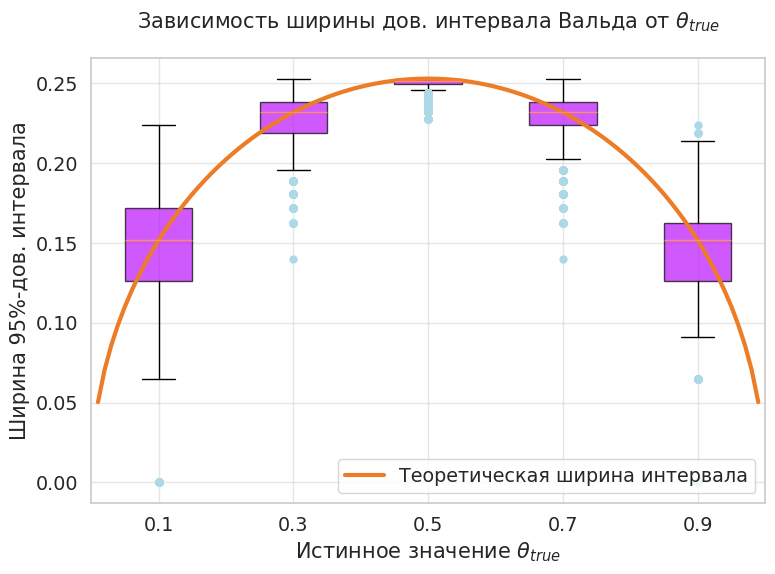

In [16]:
plt.figure(figsize=(8, 6))
plt.boxplot(
    [ci_widths[i] for i in range(len(theta_grid))],
    positions=theta_grid,
    widths=0.1,
    patch_artist=True,
    boxprops=dict(facecolor=VIOLET, alpha=0.7),
    flierprops=dict(
        markerfacecolor="lightblue",
        markeredgewidth=0,
    ),
)

plt.plot(
    theta_range,
    theoretical_width,
    color=ORANGE,
    linewidth=3,
    label="Теоретическая ширина интервала",
)

plt.xlim((0, 1))
plt.xlabel(r"Истинное значение $\theta_{true}$")
plt.ylabel(f"Ширина {ALPHA*100:.0f}%-дов. интервала")
plt.xticks(ticks=theta_grid, labels=[f"{p:.1f}" for p in theta_grid])
plt.yticks()
plt.title(r"Зависимость ширины дов. интервала Вальда от $\theta_{true}$", y=1.05)
plt.legend(loc="lower right")
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

**В зависимости от размера выборки**

При фиксированном $\theta_{true} = 0.5$ сгенерируем выборки разных размеров по заданной сетке `SAMPLE_SIZES`, и для каждого определим ширину доверительных интервалов.

In [17]:
SAMPLE_SIZES = np.arange(5, 75, 5)

ci_widths = []
for sample_size in SAMPLE_SIZES:
    # Данные
    sample = sps.bernoulli.rvs(p=THETA, size=(NUM_EXPS, sample_size))
    sample_mean = np.mean(sample, axis=-1)

    # Доверительный интервал
    left_ci, right_ci = get_wald_bern_confint(sample, alpha=ALPHA)
    ci_widths.append(right_ci - left_ci)

# Теоретическая ширина интервала
n_range = np.linspace(
    min(SAMPLE_SIZES), max(SAMPLE_SIZES), max(SAMPLE_SIZES) - min(SAMPLE_SIZES) + 1, dtype=int
)
theoretical_width = get_theoretical_ci_width_wald(THETA, n_range)

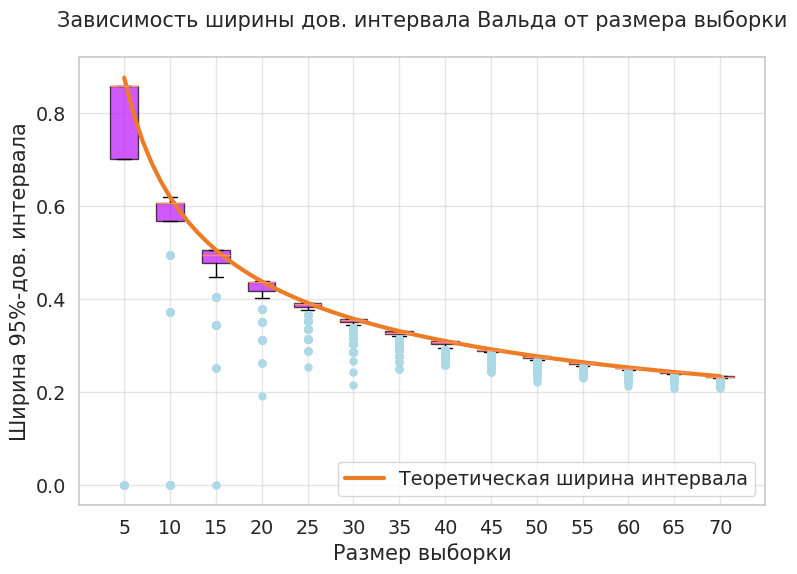

In [18]:
plt.figure(figsize=(8, 6))
plt.boxplot(
    ci_widths,
    positions=SAMPLE_SIZES,
    widths=3,
    patch_artist=True,
    boxprops=dict(facecolor=VIOLET, alpha=0.7),
    flierprops=dict(
        markerfacecolor="lightblue",
        markeredgewidth=0,
    ),
)

plt.plot(
    n_range, theoretical_width, color=ORANGE, linewidth=3, label="Теоретическая ширина интервала"
)

plt.xlabel(r"Размер выборки")
plt.ylabel(f"Ширина {ALPHA*100:.0f}%-дов. интервала")
plt.xticks(ticks=SAMPLE_SIZES)
plt.yticks()
plt.title(r"Зависимость ширины дов. интервала Вальда от размера выборки", y=1.05)
plt.legend(loc="lower right")
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

**Вывод.**

Уровень доверия доверительного интервала отражает вероятность того, что истинное значение параметра окажется между соответствущими границами интервала. При этом на практике наблюдаемое покрытие истинного значения параметра может отличаться от теории.

Ширина доверительного интервала зависит от свойств распределения, например, дисперсии, и размера выборки, а также от установленного уровня доверия. При прочих равных более узкий доверительный интервал лучше более широкого.

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока